Decision Trees  
Decision stumps  

A decision stump is a decision tree that has a single question at the root node which splits into two leaf nodes. A decision stump partitions the dataset based on a single question:  fk<θ . This is therefore the simplest decision tree that we can come up with.  

Use the following decision stump for problems 1 and 3: The root has  1000  data-points out of which  200  belong to class-1. The left child-node has  100  data-points out of which  50  belong to class-1.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['font.size'] = 15

Problem-1  
Write a function entropy that accepts the proportion of points that belong to class-1 in a node as argument and returns the entropy. Use  log2  for all computations.  

Use this function to compute the entropy of the parent node.

In [3]:
def Entropy(p):
    if p == 0 or p == 1 :
        return 0
    entropy = -p * np.log2(p) - (1-p) * np.log2(1-p)
    return entropy

parant_total = 1000
parant_class1 = 200
parant_class0 = 800
proportion_class1 = parant_class1 / parant_total

print(Entropy(proportion_class1))

0.7219280948873623


Problem-2  
Plot the entropy of a node as a function of  p , the proportion of data-points that belong to class  +1 .

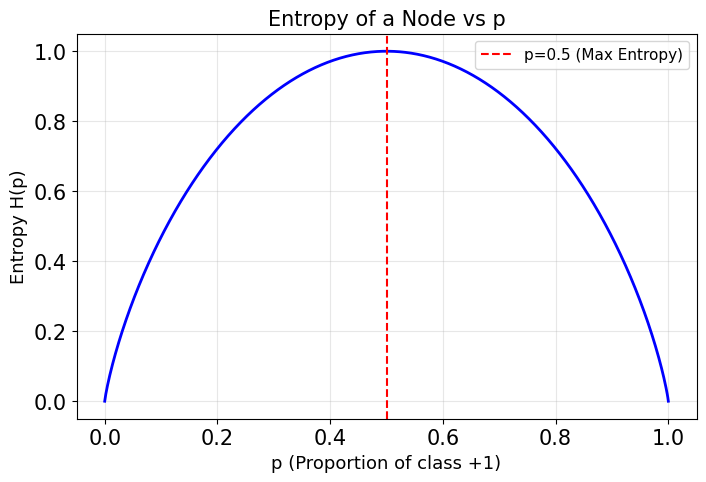

In [7]:
p_values = np.linspace(0,1,1000)
entropies = [Entropy(p) for p in p_values]

# Draw Graph

plt.figure(figsize=(8,5))
plt.plot(p_values , entropies , color="blue" , linewidth=2)
plt.xlabel('p (Proportion of class +1)' , fontsize=13)
plt.ylabel('Entropy H(p)' , fontsize=13)
plt.title('Entropy of a Node vs p', fontsize=15)
plt.axvline(x=0.5, color='red', linestyle='--', label='p=0.5 (Max Entropy)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()


Problem-3  
Write a function IG that accepts the following arguments:  

E: entropy of the parent node Q  
El: entropy of the left child L  
Er: entropy of the right child R  
gamma: proportion of data-points in left child  

Use this function to compute the information gain for the parent node.

In [ ]:














import numpy as np
import matplotlib.pyplot as plt

def entropy(p):
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def IG(E, El, Er, gamma):
    return E - (gamma * El + (1 - gamma) * Er)

total_parent  = 1000
class1_parent = 200
p_parent      = class1_parent / total_parent

total_left    = 100
class1_left   = 50
p_left        = class1_left / total_left

total_right   = total_parent - total_left
class1_right  = class1_parent - class1_left
p_right       = class1_right / total_right

gamma = total_left / total_parent

E  = entropy(p_parent)
El = entropy(p_left)
Er = entropy(p_right)

ig = IG(E, El, Er, gamma)

print(f"Entropy Parent  (E)  = {E:.3f}")
print(f"Entropy Left    (El) = {El:.3f}")
print(f"Entropy Right   (Er) = {Er:.3f}")
print(f"Gamma                = {gamma:.3f}")
print(f"Information Gain     = {ig:.3f}")

Entropy Parent  (E)  = 0.722
Entropy Left    (El) = 1.000
Entropy Right   (Er) = 0.650
Gamma                = 0.100
Information Gain     = 0.037


Problem-4  
Consider a decision stump with  1000  data-points. Call the root node  Q  and the left and right leaf nodes  L  and  R .  

The proportion of data-points that belong to class  +1  in  Q  is equal to  0.4  
The proportion of points in the left node is equal to  0.7 , that is,  γ=0.7  
q  is the proportion of data-points that belong to class  +1  in  L  
What are the minimum ( qmin ) and maximum ( qmax ) values of  q ?


In [11]:
total = 1000
p = 0.4
gamma = 0.7

total_left = gamma * total          # 700
total_right = (1 - gamma) * total   # 300
total_class1 = p * total            # 400

min_class1_left = max(0, total_class1 - total_right)   # 400-300 = 100
max_class1_left = min(total_class1, total_left)         # min(400,700) = 400

q_min = min_class1_left / total_left
q_max = max_class1_left / total_left

print(f"q_min = {q_min:.3f}")
print(f"q_max = {q_max:.3f}")


q_min = 0.143
q_max = 0.571


Problem-5  
Using the above information, plot the information gain of the root as a function of  q , where  q∈[qmin,qmax] . Record at least two interesting observations.

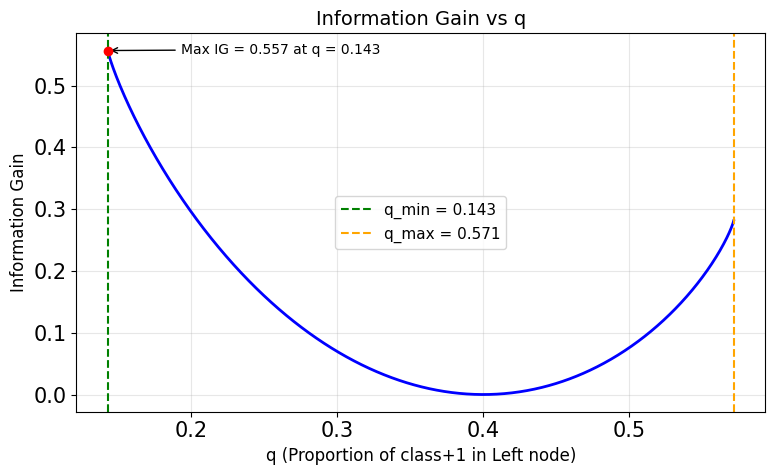

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# entropy function
# ----------------------------------------
def entropy(p):
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# ----------------------------------------
# IG function
# ----------------------------------------
def IG(E, El, Er, gamma):
    return E - (gamma * El + (1 - gamma) * Er)

# ----------------------------------------
# Given values
# ----------------------------------------
total       = 1000
p_parent    = 0.4          # proportion of class+1 in root
gamma       = 0.7          # proportion of points in left node
total_left  = 700          # 0.7 * 1000
total_right = 300          # 0.3 * 1000
total_class1 = 400         # 0.4 * 1000

# qmin and qmax (from Problem 4)
q_min = 100 / 700          # 0.143
q_max = 400 / 700          # 0.571

# ----------------------------------------
# parent entropy (fixed)
# ----------------------------------------
E = entropy(p_parent)      # entropy of root node

# ----------------------------------------
# q ki values banao (qmin se qmax tak)
# ----------------------------------------
q_values = np.linspace(q_min, q_max, 1000)
# qmin se qmax ke beech 1000 points

# ----------------------------------------
# har q ke liye IG calculate karo
# ----------------------------------------
ig_values = []

for q in q_values:
    # left node ka entropy
    El = entropy(q)
    
    # right node mein class+1 proportion nikalo
    # total class+1 = 400
    # class+1 in left = 700 * q
    # class+1 in right = 400 - 700*q
    # proportion in right = (400 - 700*q) / 300
    q_right = (total_class1 - total_left * q) / total_right
    
    # right node ka entropy
    Er = entropy(q_right)
    
    # information gain calculate karo
    ig = IG(E, El, Er, gamma)
    ig_values.append(ig)

# ----------------------------------------
# Plot karo
# ----------------------------------------
plt.figure(figsize=(8, 5))

# IG curve draw karo
plt.plot(q_values, ig_values, color='blue', linewidth=2)

# maximum IG point dhundo
max_ig       = max(ig_values)                        # maximum IG value
max_ig_index = ig_values.index(max_ig)               # uska index
q_at_max_ig  = q_values[max_ig_index]                # us index pe q ki value

# maximum point mark karo
plt.scatter([q_at_max_ig], [max_ig], color='red', zorder=5)
plt.annotate(f'Max IG = {max_ig:.3f} at q = {q_at_max_ig:.3f}',
             xy=(q_at_max_ig, max_ig),
             xytext=(q_at_max_ig + 0.05, max_ig - 0.005),
             fontsize=10,
             arrowprops=dict(arrowstyle='->'))

# qmin aur qmax pe vertical lines
plt.axvline(x=q_min, color='green', linestyle='--', label=f'q_min = {q_min:.3f}')
plt.axvline(x=q_max, color='orange', linestyle='--', label=f'q_max = {q_max:.3f}')

# labels aur title
plt.xlabel('q (Proportion of class+1 in Left node)', fontsize=12)
plt.ylabel('Information Gain', fontsize=12)
plt.title('Information Gain vs q', fontsize=14)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)   # light grid lines
plt.tight_layout()           # graph ka layout adjust karo
plt.show()

Problem-6  
We will work with the dataset X for the next five problems. Visualize the data using a scatter plot. Color the points that belong to class  +1  using "green" and those that belong to class  0  using "red".

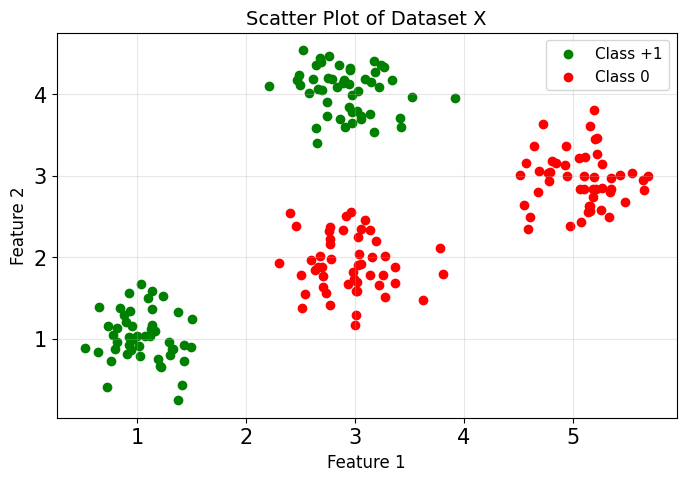

In [17]:
### Data ###
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###
rng = np.random.default_rng(seed = 1001)
n_per = 50
cov = np.eye(2) / 10
X1 = rng.multivariate_normal([1, 1], cov, n_per)
y1 = np.ones(n_per)
X2 = rng.multivariate_normal([5, 3], cov , n_per)
y2 = np.zeros(n_per)
X3 = rng.multivariate_normal([3, 4], cov, n_per)
y3 = np.ones(n_per)
X4 = rng.multivariate_normal([3, 2], cov, n_per)
y4 = np.zeros(n_per)
X = np.concatenate((X1, X2, X3, X4), axis = 0)
y = np.int64(np.concatenate((y1, y2, y3, y4)))
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###


# class+1 ke points alag karo (jahan y == 1)
X_class1 = X[y == 1]   # green points

# class 0 ke points alag karo (jahan y == 0)
X_class0 = X[y == 0]   # red points

# plot karo
plt.figure(figsize=(8, 5))

# class+1 ke points green color se plot karo
plt.scatter(X_class1[:, 0], X_class1[:, 1], color='green', label='Class +1')
# X_class1[:, 0] → saare rows ki pehli column (feature 1)
# X_class1[:, 1] → saare rows ki doosri column (feature 2)

# class 0 ke points red color se plot karo
plt.scatter(X_class0[:, 0], X_class0[:, 1], color='red', label='Class 0')

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Scatter Plot of Dataset X', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

Problem-7  
If you were to use a decision stump as a classifier:  

What is the best question  fk<θ ?  
enter the feature index,  k  (use zero-indexing)  
enter the value of  θ  
What is the information gain for this question?  

Write the function named best_split to solve this problem:  

The function should accept the feature matrix X and the label vector y as arguements. It should return the tuple (feat_best, value_best, ig_best).

In [19]:
import numpy as np
import matplotlib.pyplot as plt

### Data ###
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###
rng = np.random.default_rng(seed = 1001)
n_per = 50
cov = np.eye(2) / 10
X1 = rng.multivariate_normal([1, 1], cov, n_per)
y1 = np.ones(n_per)
X2 = rng.multivariate_normal([5, 3], cov , n_per)
y2 = np.zeros(n_per)
X3 = rng.multivariate_normal([3, 4], cov, n_per)
y3 = np.ones(n_per)
X4 = rng.multivariate_normal([3, 2], cov, n_per)
y4 = np.zeros(n_per)
X = np.concatenate((X1, X2, X3, X4), axis = 0)
y = np.int64(np.concatenate((y1, y2, y3, y4)))
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###

# ----------------------------------------
# entropy function (Problem 1 se)
# ----------------------------------------
def entropy(p):
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# ----------------------------------------
# IG function (Problem 3 se)
# ----------------------------------------
def IG(E, El, Er, gamma):
    return E - (gamma * El + (1 - gamma) * Er)

# ----------------------------------------
# best_split function
# ----------------------------------------
def best_split(X, y):
    n = len(y)                          # total points
    
    # parent node ki entropy
    p_parent = np.sum(y == 1) / n       # proportion of class+1 in parent
    E = entropy(p_parent)               # parent entropy

    best_ig    = -1                     # abhi tak ka best IG (shuruaat mein -1)
    feat_best  = None                   # best feature index
    value_best = None                   # best threshold value

    # har feature ke liye loop karo (k=0 aur k=1)
    for k in range(X.shape[1]):
        # us feature ki saari unique values nikalo
        thresholds = np.unique(X[:, k])
        # np.unique → sorted unique values deta hai
        # X[:, k]  → kth feature ki saari values (saare rows)

        # har threshold try karo
        for theta in thresholds:
            # left node → fk < theta wale points
            left_mask  = X[:, k] < theta
            # right node → fk >= theta wale points
            right_mask = ~left_mask
            # ~ matlab NOT → jo left mein nahi woh right mein

            n_left  = np.sum(left_mask)    # left mein kitne points
            n_right = np.sum(right_mask)   # right mein kitne points

            # agar koi node empty hai toh skip karo
            if n_left == 0 or n_right == 0:
                continue

            # left node ka proportion of class+1
            p_left = np.sum(y[left_mask] == 1) / n_left

            # right node ka proportion of class+1
            p_right = np.sum(y[right_mask] == 1) / n_right

            # left aur right ki entropy
            El = entropy(p_left)
            Er = entropy(p_right)

            # gamma = proportion of points in left node
            gamma = n_left / n

            # information gain calculate karo
            ig = IG(E, El, Er, gamma)

            # agar yeh IG abhi tak ke best se zyada hai
            if ig > best_ig:
                best_ig    = ig       # best IG update karo
                feat_best  = k        # best feature update karo
                value_best = theta    # best threshold update karo

    return (feat_best, value_best, best_ig)

# ----------------------------------------
# best split nikalo
# ----------------------------------------
feat_best, value_best, ig_best = best_split(X, y)

print(f"Best Feature Index (k) = {feat_best}")
print(f"Best Threshold (theta) = {value_best:.3f}")
print(f"Best Information Gain  = {ig_best:.3f}")


Best Feature Index (k) = 0
Best Threshold (theta) = 2.300
Best Information Gain  = 0.319


Problem-8  
Grow a decision tree for this problem. You may have to use two programming concepts:  

recursion  
binary trees  

Once you have grown the tree, answer the following questions:  

How many internal nodes does your tree have?  
How many leaf nodes does it have?

In [21]:
# ----------------------------------------
# entropy function
# ----------------------------------------
def entropy(p):
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# ----------------------------------------
# IG function
# ----------------------------------------
def IG(E, El, Er, gamma):
    return E - (gamma * El + (1 - gamma) * Er)

# ----------------------------------------
# best_split function (Problem 7 se)
# ----------------------------------------
def best_split(X, y):
    n = len(y)
    p_parent = np.sum(y == 1) / n
    E = entropy(p_parent)

    best_ig    = -1
    feat_best  = None
    value_best = None

    for k in range(X.shape[1]):
        thresholds = np.unique(X[:, k])

        for theta in thresholds:
            left_mask  = X[:, k] < theta
            right_mask = ~left_mask

            n_left  = np.sum(left_mask)
            n_right = np.sum(right_mask)

            if n_left == 0 or n_right == 0:
                continue

            p_left  = np.sum(y[left_mask] == 1) / n_left
            p_right = np.sum(y[right_mask] == 1) / n_right

            El    = entropy(p_left)
            Er    = entropy(p_right)
            gamma = n_left / n
            ig    = IG(E, El, Er, gamma)

            if ig > best_ig:
                best_ig    = ig
                feat_best  = k
                value_best = theta

    return (feat_best, value_best, best_ig)

# ----------------------------------------
# Node class - binary tree ka ek node
# ----------------------------------------
class Node:
    def __init__(self):
        self.feature   = None    # kaunsa feature pe split hua
        self.threshold = None    # kaunsi value pe split hua
        self.left      = None    # left child node
        self.right     = None    # right child node
        self.label     = None    # leaf node ka label (0 ya 1)
        self.is_leaf   = False   # leaf hai ya nahi

# ----------------------------------------
# grow_tree function - recursion use karta hai
# ----------------------------------------
def grow_tree(X, y):
    node = Node()    # naya node banao

    # stopping condition 1: node pure hai (saare ek hi class ke)
    if len(np.unique(y)) == 1:
        node.is_leaf = True
        node.label   = y[0]       # jo bhi class hai woh label
        return node

    # best split dhundo
    feat, theta, ig = best_split(X, y)

    # stopping condition 2: koi achha split nahi mila
    if ig <= 0:
        node.is_leaf = True
        # majority class label assign karo
        node.label   = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
        return node

    # split karo
    left_mask  = X[:, feat] < theta
    right_mask = ~left_mask

    # node mein split info store karo
    node.feature   = feat
    node.threshold = theta

    # recursion - left aur right subtree grow karo
    node.left  = grow_tree(X[left_mask],  y[left_mask])
    node.right = grow_tree(X[right_mask], y[right_mask])

    return node

# ----------------------------------------
# count_nodes - internal aur leaf nodes count karo
# ----------------------------------------
def count_nodes(node):
    # base case: leaf node
    if node.is_leaf:
        return 0, 1    # (internal=0, leaf=1)

    # left subtree count karo
    left_internal,  left_leaf  = count_nodes(node.left)
    # right subtree count karo
    right_internal, right_leaf = count_nodes(node.right)

    # current node internal hai + children ka count
    total_internal = 1 + left_internal + right_internal
    total_leaf     = left_leaf + right_leaf

    return total_internal, total_leaf

# ----------------------------------------
# tree print karo (optional - dekhne ke liye)
# ----------------------------------------
def print_tree(node, depth=0):
    indent = "  " * depth    # depth ke hisaab se indentation

    if node.is_leaf:
        print(f"{indent}Leaf → Label: {node.label}")
        return

    print(f"{indent}[Feature {node.feature} < {node.threshold:.3f}]")
    print(f"{indent}Left:")
    print_tree(node.left,  depth + 1)
    print(f"{indent}Right:")
    print_tree(node.right, depth + 1)

# ----------------------------------------
# Tree grow karo
# ----------------------------------------
tree = grow_tree(X, y)

# Nodes count karo
internal_nodes, leaf_nodes = count_nodes(tree)

print(f"Internal Nodes = {internal_nodes}")
print(f"Leaf Nodes     = {leaf_nodes}")
print()
print_tree(tree)


Internal Nodes = 3
Leaf Nodes     = 4

[Feature 0 < 2.300]
Left:
  Leaf → Label: 1
Right:
  [Feature 1 < 3.401]
  Left:
    Leaf → Label: 0
  Right:
    [Feature 0 < 4.729]
    Left:
      Leaf → Label: 1
    Right:
      Leaf → Label: 0


Problem-9 

Predict the label of the point  (3,4) .

In [22]:
def predict(node, x):
    if node.is_leaf:
        return node.label
    if x[node.feature] < node.threshold:
        return predict(node.left, x)
    else:
        return predict(node.right, x)

test_point = np.array([3, 4])
predicted_label = predict(tree, test_point)

if predicted_label == 1:
    print("Green")
else:
    print("Red")

Green


Problem-10  
Plot the decision boundary.

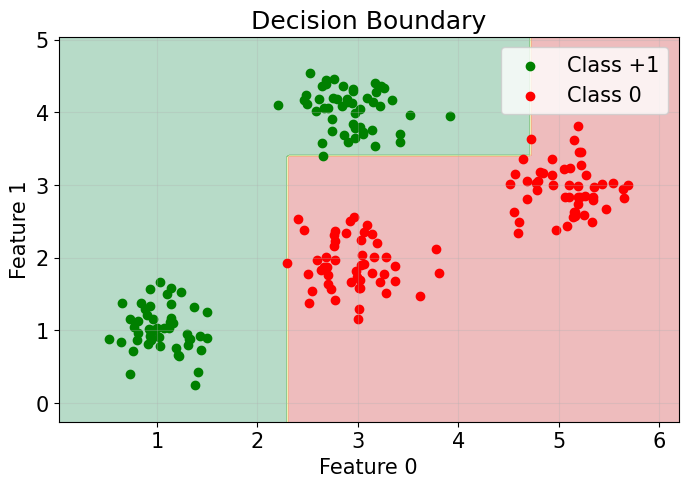

In [23]:
# feature 0 aur feature 1 ki range nikalo
x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# grid banao - har point pe prediction karenge
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 200),
                        np.linspace(x1_min, x1_max, 200))

# grid ke har point ka label predict karo
grid_points = np.c_[xx0.ravel(), xx1.ravel()]
predictions = np.array([predict(tree, point) for point in grid_points])
predictions = predictions.reshape(xx0.shape)

# plot karo
plt.figure(figsize=(8, 5))

# decision boundary (background colors)
plt.contourf(xx0, xx1, predictions, alpha=0.3, cmap='RdYlGn')

# actual data points plot karo
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='Class +1')
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')

plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('Decision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

KNN

In [24]:
### Data ###
### DO NOT EDIT THIS CELL ###
rng = np.random.default_rng(seed = 1001)
X = rng.uniform(-10, 10, (100, 2))
y = np.int32(np.zeros(X.shape[0]))
y[X[:, 1] > X[:, 0]] = 1
X = np.concatenate((X, 
                   rng.multivariate_normal([-5, 5], np.eye(2), 10)), 
                   axis = 0)
y = np.concatenate((y, np.int32(np.zeros(10))))
### DO NOT EDIT THIS CELL ###

Problem-11
Visualize the data using a scatter plot. Use red for class  0  and green for class  1 .

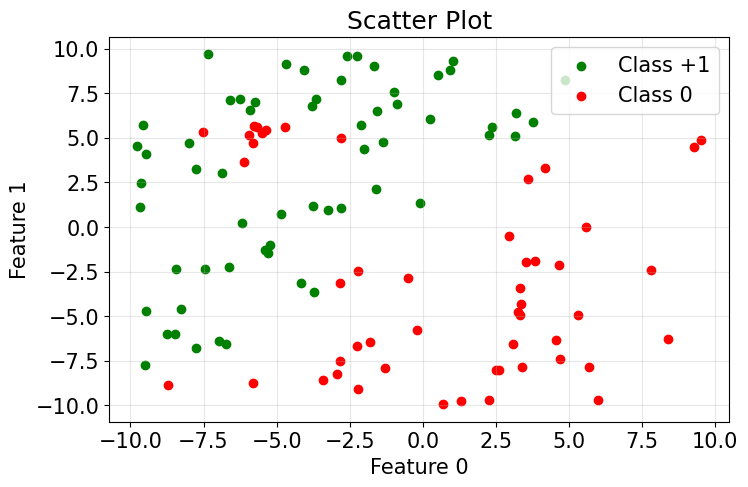

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='Class +1')
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')

plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('Scatter Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Problem-12  
Write a function predict that accepts the following arguments:  

X - feature matrix  
y - label vector  
x_test - test data-point  
k - number of neighbors  

The function should return the prediction for the point x_test. Use this function to compute the predicted label for the point  (−3,−2)  with  k=10 .

In [27]:
def predict_knn(X, y, x_test, k):
    # har training point se distance nikalo
    distances = np.sqrt(np.sum((X - x_test) ** 2, axis=1))
    
    # k nearest neighbors ke indices nikalo (sorted by distance)
    k_nearest_indices = np.argsort(distances)[:k]
    
    # un k neighbors ke labels nikalo
    k_nearest_labels = y[k_nearest_indices]
    
    # majority vote - jis class ke zyada labels uska prediction
    if np.sum(k_nearest_labels == 1) >= np.sum(k_nearest_labels == 0):
        return 1
    else:
        return 0

# test point (-3, -2) ka label predict karo with k=10
x_test = np.array([-3, -2])
predicted_label = predict_knn(X, y, x_test, k=10)

if predicted_label == 1:
    print("Green")
else:
    print("Red")


Green


Problem-13  
Plot the decision boundary for different values of  k :  

k=1  
k=3  
k=7  
k=15  
k=31  
k=63  

Record at least two observations.

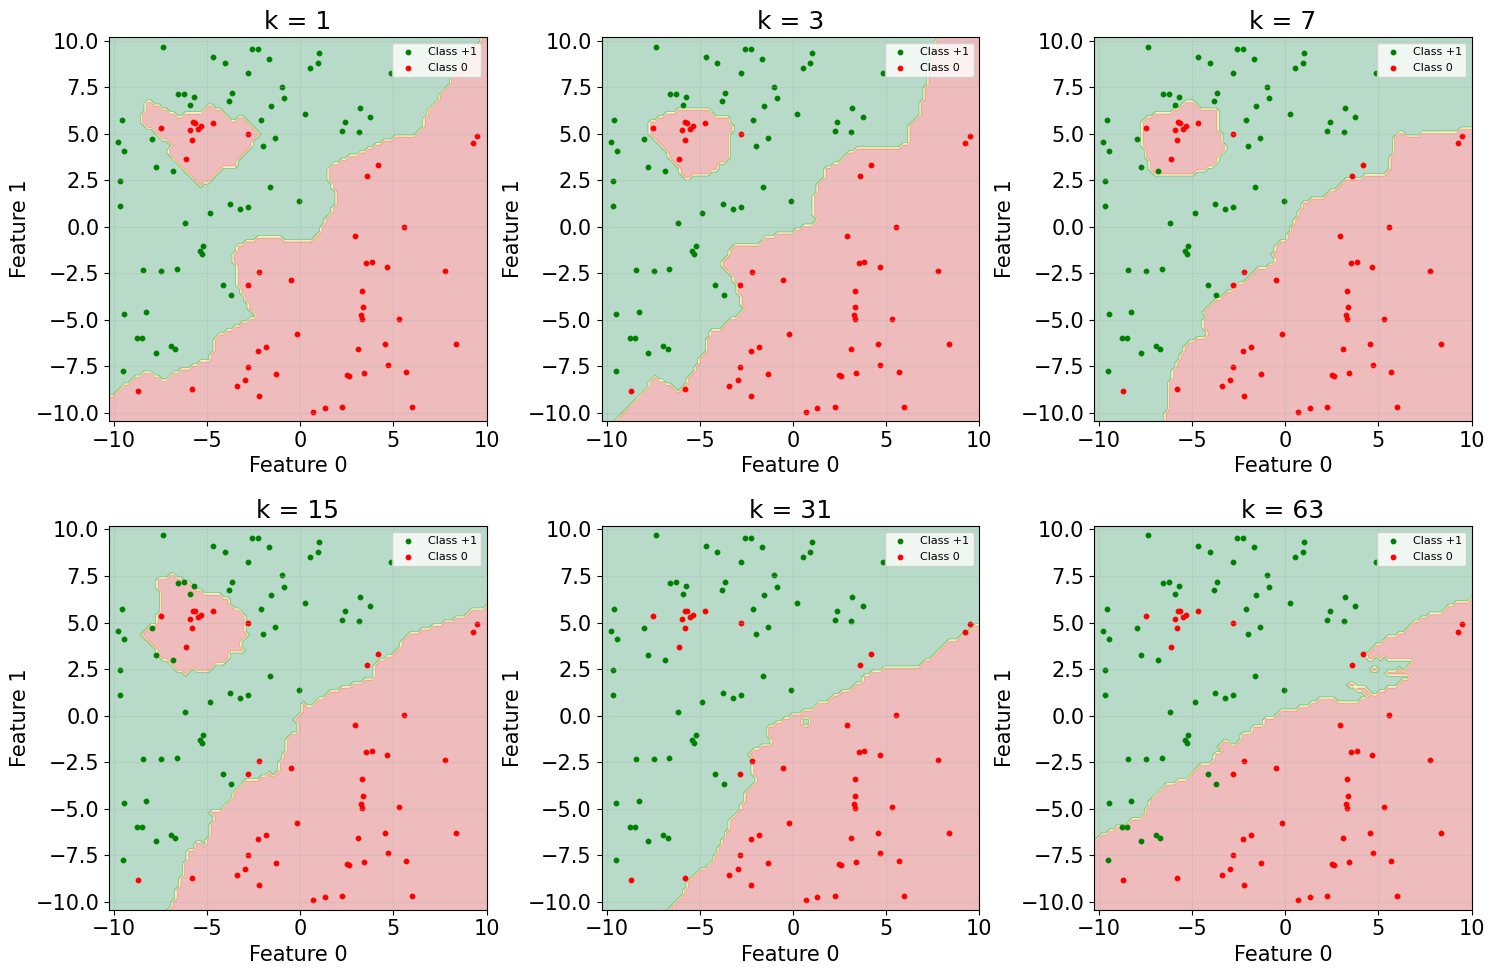

In [28]:
k_values = [1, 3, 7, 15, 31, 63]

# grid banao
x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 100),
                        np.linspace(x1_min, x1_max, 100))

grid_points = np.c_[xx0.ravel(), xx1.ravel()]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, k in enumerate(k_values):
    # har grid point ka label predict karo
    predictions = np.array([predict_knn(X, y, point, k) for point in grid_points])
    predictions = predictions.reshape(xx0.shape)

    # decision boundary plot karo
    axes[i].contourf(xx0, xx1, predictions, alpha=0.3, cmap='RdYlGn')

    # data points plot karo
    axes[i].scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='Class +1', s=10)
    axes[i].scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0', s=10)

    axes[i].set_title(f'k = {k}')
    axes[i].set_xlabel('Feature 0')
    axes[i].set_ylabel('Feature 1')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()